In [262]:
import sys
import pathlib

# Make sure the repo root is importable
root = pathlib.Path.cwd()
if not (root / "models").exists():
    root = root.parent
root = str(root)
if root not in sys.path:
    sys.path.append(root)

In [263]:
from models.themes import KDETheme
from generators import CIELChGenerator
from layers.frames import HorizontalFrame

In [264]:
# Magic vars
THEME_PATH = r"M:\dev\rcmreloaded\data\themes\sunset.rcmt"
N_COLOURS = 4         # number of colours in the frame
MAX_ATTEMPTS = 100000  # safeguard against an over-restrictive theme

In [265]:
# Load a serialized theme
with open(THEME_PATH, "rb") as f:
    theme = KDETheme.deserialize(f.read())

theme.name

'sunset'

In [266]:
# Generate colours, keeping only those the theme accepts
generator = CIELChGenerator()

colours = []
attempts = 0
while len(colours) < N_COLOURS:
    if attempts >= MAX_ATTEMPTS:
        raise RuntimeError(
            f"Only accepted {len(colours)}/{N_COLOURS} colours after {attempts} attempts "
            f"- the theme may be too restrictive."
        )
    colour = generator.single()
    attempts += 1
    if theme.accepted(colour):
        colours.append(colour)

print(f"Accepted {N_COLOURS} colours after {attempts} attempts")
[c.hexcode for c in colours]

Accepted 4 colours after 597 attempts


['#DEA481', '#F6BA96', '#E4923B', '#F4AC47']

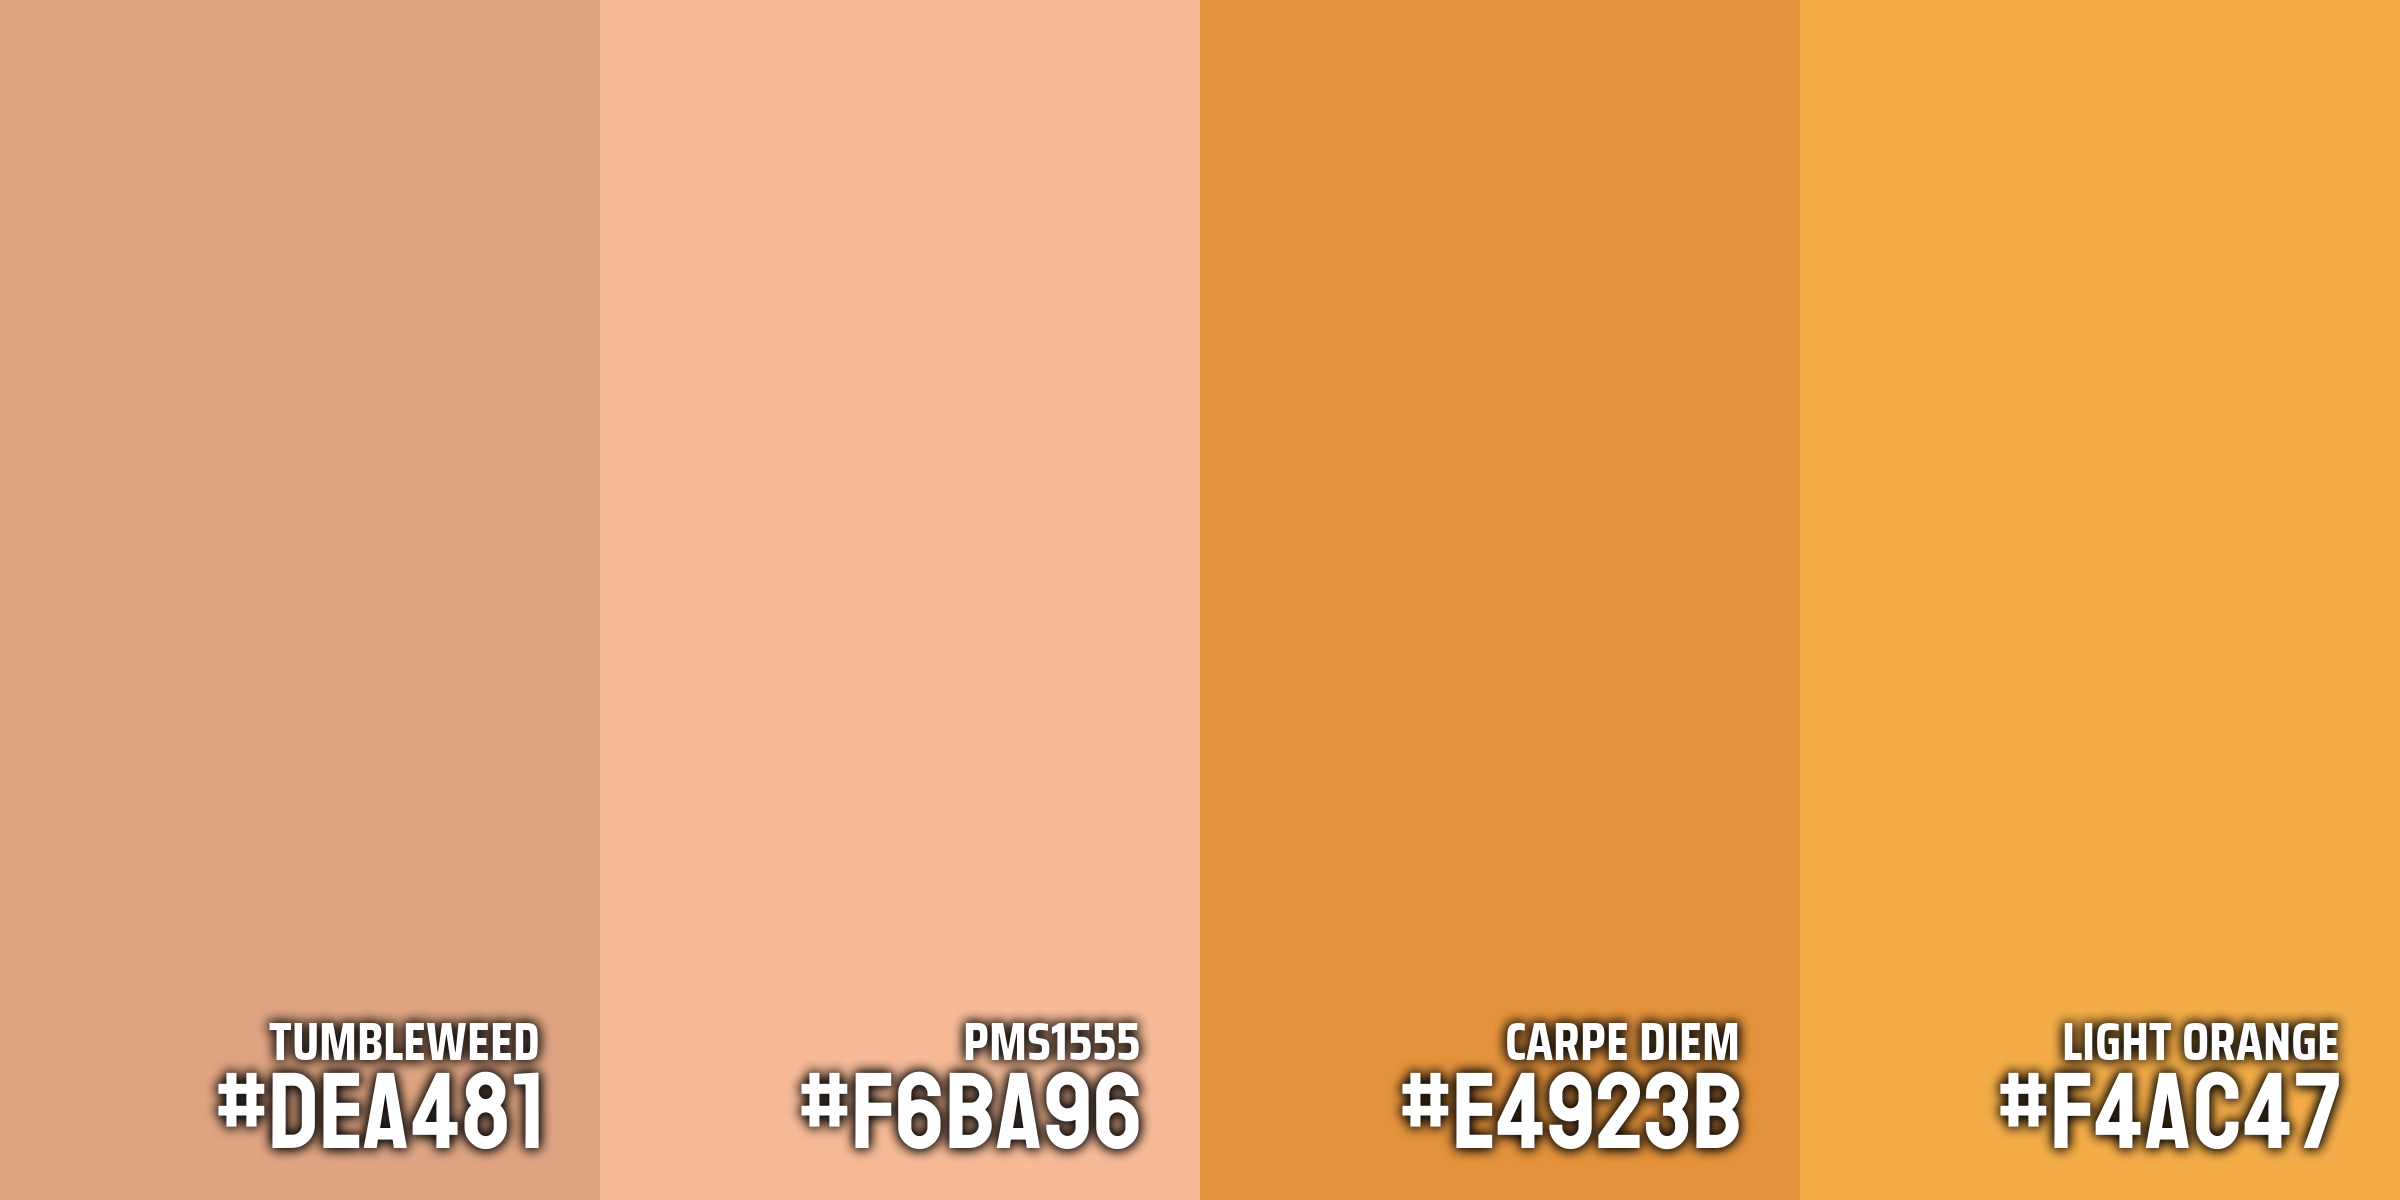

In [267]:
# Build a frame from the accepted colours
frame = HorizontalFrame((600, 1200))
image = frame.construct_frame(colours)
image